# Sentiment Analysis with RoBERTa Large



In [ ]:
import torch
import pandas as pd
import numpy as np
from datasets import Dataset, DatasetDict
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

c:\Users\belw2\Desktop\ALL\ML && DL\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## Data Preparation



In [ ]:
from pathlib import Path

data_dir = Path.cwd()
train_csv_path = data_dir / "train (1).csv"
test_csv_path = data_dir / "test (1).csv"

df_train = pd.read_csv(train_csv_path)
df_test = pd.read_csv(test_csv_path)

print("Train columns:", df_train.columns.tolist())
print("Test columns:", df_test.columns.tolist())

train_text_candidates = ["text", "sentence", "review", "content"]
train_label_candidates = ["label", "sentiment", "target", "class"]
test_text_candidates = ["text", "sentence", "review", "content"]

train_text_col = next((c for c in train_text_candidates if c in df_train.columns), None)
train_label_col = next((c for c in train_label_candidates if c in df_train.columns), None)
test_text_col = next((c for c in test_text_candidates if c in df_test.columns), None)

if train_text_col is None or train_label_col is None:
    raise ValueError(
        f"Could not infer train text/label columns from {df_train.columns.tolist()}. "
        "Please set train_text_col and train_label_col manually."
    )

if test_text_col is None:
    raise ValueError(
        f"Could not infer test text column from {df_test.columns.tolist()}. "
        "Please set test_text_col manually."
    )

df_train = df_train.rename(columns={train_text_col: "text", train_label_col: "label"})
df_test = df_test.rename(columns={test_text_col: "text"})

df_train = df_train.dropna(subset=["text", "label"]).copy()
df_test = df_test.dropna(subset=["text"]).copy()

if df_train["label"].dtype == object:
    label_values = sorted(df_train["label"].astype(str).unique())
    label2id = {label: idx for idx, label in enumerate(label_values)}
    id2label = {idx: label for label, idx in label2id.items()}
    df_train["label"] = df_train["label"].astype(str).map(label2id)
    print("Label mapping:", label2id)
else:
    id2label = None

dataset = DatasetDict({
    "train": Dataset.from_pandas(df_train, preserve_index=False),
    "test": Dataset.from_pandas(df_test, preserve_index=False),
})

print("Train dataset size:", len(dataset["train"]))
print("Test/prediction dataset size:", len(dataset["test"]))

Train columns: ['id', 'sentence', 'sentiment']
Test columns: ['id', 'text']
Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
Train dataset size: 64000
Test/prediction dataset size: 16000


In [ ]:
from transformers import AutoTokenizer

model_checkpoint = "roberta-large"

try:
    tokenizer = AutoTokenizer.from_pretrained(
        model_checkpoint,
        local_files_only=True,
        use_fast=True,
    )
    print(f"Loaded tokenizer from local cache: {model_checkpoint}")
except Exception:
    tokenizer = AutoTokenizer.from_pretrained(
        model_checkpoint,
        use_fast=True,
    )
    print(f"Downloaded tokenizer: {model_checkpoint}")

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=192)

if "validation" not in dataset:
    encoded_train = dataset["train"].class_encode_column("label")
    split_dataset = encoded_train.train_test_split(
        test_size=0.1,
        seed=42,
        stratify_by_column="label",
    )
    dataset["train"] = split_dataset["train"]
    dataset["validation"] = split_dataset["test"]

tokenized_train = dataset["train"].map(tokenize_function, batched=True)
tokenized_validation = dataset["validation"].map(tokenize_function, batched=True)
tokenized_test = dataset["test"].map(tokenize_function, batched=True)

tokenized_train = tokenized_train.remove_columns([
    c for c in tokenized_train.column_names
    if c not in ["input_ids", "attention_mask", "token_type_ids", "label"]
])
tokenized_validation = tokenized_validation.remove_columns([
    c for c in tokenized_validation.column_names
    if c not in ["input_ids", "attention_mask", "token_type_ids", "label"]
])
tokenized_test = tokenized_test.remove_columns([
    c for c in tokenized_test.column_names
    if c not in ["input_ids", "attention_mask", "token_type_ids"]
])

print("Tokenization complete.")
print("Train size:", len(tokenized_train))
print("Validation size:", len(tokenized_validation))
print("Test size:", len(tokenized_test))

c:\Users\belw2\Desktop\ALL\ML && DL\venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\belw2\.cache\huggingface\hub\models--roberta-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Downloaded tokenizer: roberta-large


Map: 100%|██████████| 16000/16000 [00:00<00:00, 22496.50 examples/s]

Tokenization complete.
Train size: 57600
Validation size: 6400
Test size: 16000


## Tokenization and Tensor Formatting




In [ ]:
required_train_cols = ["input_ids", "attention_mask", "label"]
required_test_cols = ["input_ids", "attention_mask"]

if "token_type_ids" in tokenized_train.column_names:
    required_train_cols.insert(2, "token_type_ids")
if "token_type_ids" in tokenized_validation.column_names:
    required_val_cols = ["input_ids", "attention_mask", "token_type_ids", "label"]
else:
    required_val_cols = ["input_ids", "attention_mask", "label"]
if "token_type_ids" in tokenized_test.column_names:
    required_test_cols.append("token_type_ids")

tokenized_train.set_format(type="torch", columns=required_train_cols)
tokenized_validation.set_format(type="torch", columns=required_val_cols)
tokenized_test.set_format(type="torch", columns=required_test_cols)

print("Preprocessing complete.")
print("Train tensor columns:", required_train_cols)
print("Validation tensor columns:", required_val_cols)
print("Test tensor columns:", required_test_cols)
print("Train sample input_ids shape:", tokenized_train[0]["input_ids"].shape)
print("Validation sample input_ids shape:", tokenized_validation[0]["input_ids"].shape)
print("Test sample input_ids shape:", tokenized_test[0]["input_ids"].shape)

Preprocessing complete.
Train tensor columns: ['input_ids', 'attention_mask', 'label']
Validation tensor columns: ['input_ids', 'attention_mask', 'label']
Test tensor columns: ['input_ids', 'attention_mask']
Train sample input_ids shape: torch.Size([21])
Validation sample input_ids shape: torch.Size([192])
Test sample input_ids shape: torch.Size([23])


In [ ]:
from transformers import AutoModelForSequenceClassification

if isinstance(id2label, dict) and len(id2label) > 0:
    num_labels = len(id2label)
    id2label_model = {int(k): str(v) for k, v in id2label.items()}
    label2id_model = {v: k for k, v in id2label_model.items()}
else:
    num_labels = int(df_train["label"].nunique())
    id2label_model = {i: str(i) for i in range(num_labels)}
    label2id_model = {v: k for k, v in id2label_model.items()}

try:
    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=num_labels,
        id2label=id2label_model,
        label2id=label2id_model,
        from_tf=False,
        use_safetensors=True,
    )
    print(f"Loaded model: {model_checkpoint}")
except Exception:
    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=num_labels,
        id2label=id2label_model,
        label2id=label2id_model,
        from_tf=False,
    )
    print(f"Loaded model (fallback): {model_checkpoint}")

model.to(device)
print(f"Detected {num_labels} classes: {list(id2label_model.values())}")
print("Model loaded on device:", device)

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 7203.08it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded model: roberta-large
Detected 3 classes: ['negative', 'neutral', 'positive']
Model loaded on device: cuda


## Model and Training Setup



In [ ]:
from transformers import DataCollatorWithPadding, EarlyStoppingCallback

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")

    return {"accuracy": acc, "f1": f1}

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./custom_model_results_roberta_large",
    learning_rate=1.2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    num_train_epochs=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    logging_steps=50,
    warmup_ratio=0.1,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Trainer is ready.")
print("Train samples:", len(tokenized_train))
print("Validation samples:", len(tokenized_validation))

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer is ready.
Train samples: 57600
Validation samples: 6400


In [ ]:
from pathlib import Path

print("Starting training on custom Kaggle dataset...")
output_dir = Path(training_args.output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

try:
    train_result = trainer.train()
    trainer.save_model()
    trainer.save_state()
    print("Training completed!")
    print("Final train loss:", float(train_result.training_loss))
except KeyboardInterrupt:
    interrupted_dir = output_dir / "interrupted-checkpoint"
    interrupted_dir.mkdir(parents=True, exist_ok=True)
    trainer.save_model(str(interrupted_dir))
    trainer.save_state()
    print("Training interrupted. Progress saved to:", str(interrupted_dir))
    print("Run this cell again to continue training safely.")
except RuntimeError as e:
    if "out of memory" in str(e).lower():
        if device == "cuda":
            torch.cuda.empty_cache()
        print("CUDA out of memory during training.")
        print("Lower per_device_train_batch_size and rerun this training cell.")
    else:
        raise

Starting training on custom Kaggle dataset...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.739130,0.317469,0.882031,0.883125
2,0.596950,0.302761,0.902344,0.901391
3,0.311260,0.463588,0.905625,0.905396
4,0.276258,0.525827,0.906563,0.905504


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.10it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

Training completed!
Final train loss: 0.516399143603113


## Evaluation, Submission, and Visualization



In [ ]:
from pathlib import Path
from transformers.utils.notebook import NotebookProgressCallback

trainer.remove_callback(NotebookProgressCallback)

eval_results = trainer.evaluate(eval_dataset=tokenized_validation)
print(f"Evaluation Results: {eval_results}")

predictions_output = trainer.predict(tokenized_validation)
predictions = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

conf_matrix = confusion_matrix(true_labels, predictions)
print("\nConfusion Matrix:")
print(conf_matrix)

f1 = f1_score(true_labels, predictions, average="weighted")
acc = accuracy_score(true_labels, predictions)
print(f"\nFinal Validation Accuracy: {acc * 100:.2f}%")
print(f"Final Validation F1-Score: {f1:.4f}")

test_predictions_output = trainer.predict(tokenized_test)
test_predictions = np.argmax(test_predictions_output.predictions, axis=-1)
print("\nGenerated test predictions:", len(test_predictions))

if "id" not in df_test.columns:
    raise ValueError("df_test must contain an 'id' column for submission generation.")

if isinstance(id2label, dict) and len(id2label) > 0:
    sentiment_labels = [id2label[int(pred)] for pred in test_predictions]
else:
    sentiment_labels = [str(pred) for pred in test_predictions]

submission = pd.DataFrame({
    "id": df_test["id"].astype(int).values,
    "sentiment": sentiment_labels,
})

submission_path = Path.cwd() / "submission.csv"
submission.to_csv(submission_path, index=False)
print(f"\nSubmission saved to: {submission_path}")
print(submission.head(10))

Evaluation Results: {'eval_loss': 0.5258266925811768, 'eval_accuracy': 0.9065625, 'eval_f1': 0.9055040659286057, 'eval_runtime': 19.1628, 'eval_samples_per_second': 333.98, 'eval_steps_per_second': 20.874, 'epoch': 4.0}

Confusion Matrix:
[[2381   69  110]
 [  98  482  124]
 [ 108   89 2939]]

Final Validation Accuracy: 90.66%
Final Validation F1-Score: 0.9055

Generated test predictions: 16000

Submission saved to: c:\Users\belw2\Desktop\ALL\ML && DL\ML-DL-projects\submission.csv
   id sentiment
0   0   neutral
1   1  negative
2   2  positive
3   3  negative
4   4  positive
5   5   neutral
6   6  negative
7   7  negative
8   8  positive
9   9  negative


## Prediction Distribution Plot



Predicted sentiment counts:
negative    6374
neutral     2040
positive    7586
Name: count, dtype: Int64


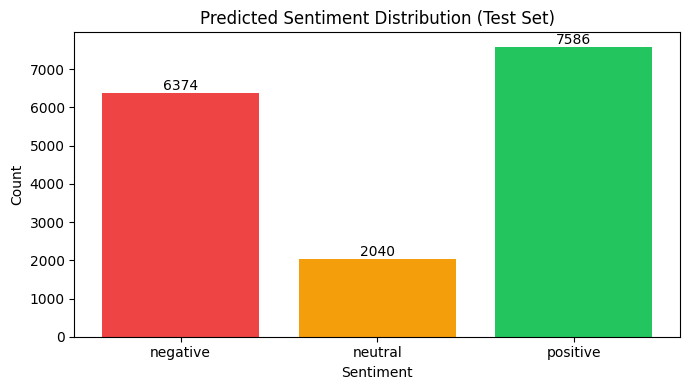

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

if "test_predictions" not in globals():
    raise ValueError("Run the prediction cell first so 'test_predictions' is available.")

if isinstance(id2label, dict) and len(id2label) > 0:
    predicted_sentiments = pd.Series([id2label[int(p)] for p in test_predictions], dtype="string")
else:
    predicted_sentiments = pd.Series(test_predictions, dtype="string")

predicted_sentiments = predicted_sentiments.str.strip().str.lower()
order = ["negative", "neutral", "positive"]
pred_counts = predicted_sentiments.value_counts().reindex(order, fill_value=0)

print("Predicted sentiment counts:")
print(pred_counts)

plt.figure(figsize=(7, 4))
bars = plt.bar(pred_counts.index, pred_counts.values, color=["#ef4444", "#f59e0b", "#22c55e"])
plt.title("Predicted Sentiment Distribution (Test Set)")
plt.xlabel("Sentiment")
plt.ylabel("Count")

for bar in bars:
    h = int(bar.get_height())
    plt.text(bar.get_x() + bar.get_width() / 2, h, f"{h}", ha="center", va="bottom")

plt.tight_layout()
plt.show()